In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from safety_formation.controllers.cbf import CentralizedHOCBF, build_centralized_hocbf_constraints, CentralizedCBF, CBFTopology
from safety_formation.formation import Agent,Topology

In [27]:
import numpy as np
import copy

# ============================================================
# Common simulation configuration
# ============================================================
N = 30
R_circle = 150.0
dt = 0.1
T_max = 60.0
steps = int(T_max / dt)

d_min = 18.0

# Nominal controller
k1 = 0.055
k2 = 0.4

# Agent limits
alpha_val = 10.0
beta_val = 20.0

# CBF / HOCBF parameters
gamma = 2e-3
k1_hocbf = 2
k2_hocbf = 1.0


# ============================================================
# Create identical initial agents
# ============================================================
agents_initial = []

for i in range(N):
    angle = 2 * np.pi * i / N

    x0 = np.array([
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ])

    # Opposite-side target
    target_pos = -x0[:2] - 10

    ag = Agent(
        agent_id=i,
        x0=x0,
        f_target=[0.0, 0.0, 0.0, 0.0],
        alpha=alpha_val,
        beta=beta_val
    )

    ag.target = target_pos.copy()
    agents_initial.append(ag)


# ============================================================
# Separate copies for CBF and HOCBF
# ============================================================
agents_cbf = copy.deepcopy(agents_initial)
agents_hocbf = copy.deepcopy(agents_initial)


# ============================================================
# SAME topology for fair comparison
# ============================================================
adj_matrix = np.ones((N, N)) - np.eye(N)

topology_cbf = Topology(
    num_agents=N,
    adjacency_matrix=adj_matrix.copy()
)

topology_hocbf = Topology(
    num_agents=N,
    adjacency_matrix=adj_matrix.copy()
)


# ============================================================
# Safety filters
# ============================================================
cbf_filter = CentralizedCBF(
    gamma=gamma,
    safety_dis=d_min
)

hocbf_filter = CentralizedHOCBF(
    k1_hocbf=k1_hocbf,
    k2_hocbf=k2_hocbf,
    safety_dis=d_min
)


# ============================================================
# Histories - CBF
# ============================================================
history_cbf = [[] for _ in range(N)]
u_nom_hist_cbf = [[] for _ in range(N)]
u_safe_hist_cbf = [[] for _ in range(N)]
min_dist_hist_cbf = []


# ============================================================
# Histories - HOCBF
# ============================================================
history_hocbf = [[] for _ in range(N)]
u_nom_hist_hocbf = [[] for _ in range(N)]
u_safe_hist_hocbf = [[] for _ in range(N)]
min_dist_hist_hocbf = []


print("=== COMPARISON SETUP ===")
print(f"N               = {N}")
print(f"dt              = {dt}")
print(f"T_max           = {T_max}")
print(f"d_min           = {d_min}")
print(f"CBF gamma       = {gamma}")
print(f"HOCBF gains     = ({k1_hocbf}, {k2_hocbf})")
print(f"alpha           = {alpha_val}")
print(f"PD gains   = ({k1}, {k2})")
print("========================")

=== COMPARISON SETUP ===
N               = 30
dt              = 0.1
T_max           = 60.0
d_min           = 18.0
CBF gamma       = 0.002
HOCBF gains     = (2, 1.0)
alpha           = 10.0
PD gains   = (0.055, 0.4)


In [28]:
# ============================================================
# HOCBF simulation
# ============================================================

history_hocbf = [[] for _ in range(N)]
u_nom_hist_hocbf = [[] for _ in range(N)]
u_safe_hist_hocbf = [[] for _ in range(N)]

delta_u_hist_hocbf = []
min_dist_hist_hocbf = []

for k in range(steps):

    # --- Nominal control ---
    u_nom_all = []

    for agent in agents_hocbf:
        x = agent.state.flatten()

        u_nom = (
            -k1 * (x[:2] - agent.target)
            -k2 * x[2:4]
        )

        u_nom_all.append(u_nom)

    u_nom_all = np.array(u_nom_all)


    # --- HOCBF safety filter ---
    u_safe_all = hocbf_filter.compute_safe_control(
        all_agents=agents_hocbf,
        topology=topology_hocbf,
        u_nom=u_nom_all
    )


    # --- Intervention magnitude ---
    delta_u = np.linalg.norm(
        u_safe_all - u_nom_all,
        axis=1
    )

    delta_u_hist_hocbf.append(delta_u)


    # --- Minimum pairwise distance ---
    min_dist = np.inf

    for i in range(N):
        for j in range(i + 1, N):
            dist = np.linalg.norm(
                agents_hocbf[i].pos.flatten()
                - agents_hocbf[j].pos.flatten()
            )

            if dist < min_dist:
                min_dist = dist

    min_dist_hist_hocbf.append(min_dist)


    # --- Store current data ---
    for i in range(N):
        history_hocbf[i].append(
            agents_hocbf[i].state.flatten().copy()
        )

        u_nom_hist_hocbf[i].append(
            u_nom_all[i].copy()
        )

        u_safe_hist_hocbf[i].append(
            u_safe_all[i].copy()
        )


    # --- Physics update ---
    for i, agent in enumerate(agents_hocbf):
        agent.update_physics(
            u_safe_all[i],
            dt
        )


# ============================================================
# Convert HOCBF data to arrays
# ============================================================

history_hocbf = [
    np.array(h)
    for h in history_hocbf
]

u_nom_hist_hocbf = [
    np.array(h)
    for h in u_nom_hist_hocbf
]

u_safe_hist_hocbf = [
    np.array(h)
    for h in u_safe_hist_hocbf
]

delta_u_hist_hocbf = np.array(delta_u_hist_hocbf)
min_dist_hist_hocbf = np.array(min_dist_hist_hocbf)

time = np.arange(steps) * dt


# ============================================================
# HOCBF metrics
# ============================================================

eps = 1e-3

# Intervention of whole system
delta_u_total_hocbf = np.linalg.norm(
    delta_u_hist_hocbf,
    axis=1
)

active_hocbf = (
    delta_u_total_hocbf > eps
)

active_idx = np.where(
    active_hocbf
)[0]

if len(active_idx) > 0:
    t_start_hocbf = time[active_idx[0]]
    t_end_hocbf = time[active_idx[-1]]
    active_duration_hocbf = np.sum(active_hocbf) * dt
else:
    t_start_hocbf = np.nan
    t_end_hocbf = np.nan
    active_duration_hocbf = 0.0

peak_intervention_hocbf = np.max(
    delta_u_total_hocbf
)

intervention_effort_hocbf = np.sum(
    delta_u_total_hocbf
) * dt

min_distance_hocbf = np.min(
    min_dist_hist_hocbf
)

print("\n=== HOCBF RESULTS ===")
print(f"intervention start  = {t_start_hocbf:.3f} s")
print(f"intervention end    = {t_end_hocbf:.3f} s")
print(f"active duration     = {active_duration_hocbf:.3f} s")
print(f"peak intervention   = {peak_intervention_hocbf:.3f}")
print(f"intervention effort = {intervention_effort_hocbf:.3f}")
print(f"minimum distance    = {min_distance_hocbf:.3f} m")


=== HOCBF RESULTS ===
intervention start  = 0.000 s
intervention end    = 43.400 s
active duration     = 43.100 s
peak intervention   = 80.741
intervention effort = 1296.959
minimum distance    = 17.983 m


In [24]:
# ============================================================
# CBF simulation
# ============================================================

history_cbf = [[] for _ in range(N)]
u_nom_hist_cbf = [[] for _ in range(N)]
u_safe_hist_cbf = [[] for _ in range(N)]

delta_u_hist_cbf = []
min_dist_hist_cbf = []

for k in range(steps):

    # --- Nominal control ---
    u_nom_all = []

    for agent in agents_cbf:
        x = agent.state.flatten()

        u_nom = (
            -k1 * (x[:2] - agent.target)
            -k2 * x[2:4]
        )

        u_nom_all.append(u_nom)

    u_nom_all = np.array(u_nom_all)


    # --- CBF safety filter ---
    u_safe_all = cbf_filter.compute_safe_control(
        all_agents=agents_cbf,
        topology=topology_cbf,
        u_nom=u_nom_all
    )


    # --- Intervention magnitude ---
    delta_u = np.linalg.norm(
        u_safe_all - u_nom_all,
        axis=1
    )

    delta_u_hist_cbf.append(delta_u)


    # --- Minimum pairwise distance ---
    min_dist = np.inf

    for i in range(N):
        for j in range(i + 1, N):
            dist = np.linalg.norm(
                agents_cbf[i].pos.flatten()
                - agents_cbf[j].pos.flatten()
            )

            if dist < min_dist:
                min_dist = dist

    min_dist_hist_cbf.append(min_dist)


    # --- Store current data ---
    for i in range(N):
        history_cbf[i].append(
            agents_cbf[i].state.flatten().copy()
        )

        u_nom_hist_cbf[i].append(
            u_nom_all[i].copy()
        )

        u_safe_hist_cbf[i].append(
            u_safe_all[i].copy()
        )


    # --- Physics update ---
    for i, agent in enumerate(agents_cbf):
        agent.update_physics(
            u_safe_all[i],
            dt
        )


# ============================================================
# Convert CBF data to arrays
# ============================================================

history_cbf = [
    np.array(h)
    for h in history_cbf
]

u_nom_hist_cbf = [
    np.array(h)
    for h in u_nom_hist_cbf
]

u_safe_hist_cbf = [
    np.array(h)
    for h in u_safe_hist_cbf
]

delta_u_hist_cbf = np.array(delta_u_hist_cbf)
min_dist_hist_cbf = np.array(min_dist_hist_cbf)


# ============================================================
# CBF metrics
# ============================================================

delta_u_total_cbf = np.linalg.norm(
    delta_u_hist_cbf,
    axis=1
)

active_cbf = (
    delta_u_total_cbf > eps
)

active_idx = np.where(
    active_cbf
)[0]

if len(active_idx) > 0:
    t_start_cbf = time[active_idx[0]]
    t_end_cbf = time[active_idx[-1]]
    active_duration_cbf = np.sum(active_cbf) * dt
else:
    t_start_cbf = np.nan
    t_end_cbf = np.nan
    active_duration_cbf = 0.0

peak_intervention_cbf = np.max(
    delta_u_total_cbf
)

intervention_effort_cbf = np.sum(
    delta_u_total_cbf
) * dt

min_distance_cbf = np.min(
    min_dist_hist_cbf
)

print("\n=== CBF RESULTS ===")
print(f"intervention start  = {t_start_cbf:.3f} s")
print(f"intervention end    = {t_end_cbf:.3f} s")
print(f"active duration     = {active_duration_cbf:.3f} s")
print(f"peak intervention   = {peak_intervention_cbf:.3f}")
print(f"intervention effort = {intervention_effort_cbf:.3f}")
print(f"minimum distance    = {min_distance_cbf:.3f} m")


=== CBF RESULTS ===
intervention start  = 0.000 s
intervention end    = 44.900 s
active duration     = 44.700 s
peak intervention   = 86.748
intervention effort = 1274.402
minimum distance    = 18.146 m



================ CBF vs HOCBF COMPARISON ================

Metric                                CBF        HOCBF
------------------------------------------------------
Intervention start [s]              0.000        0.000
Intervention end [s]               44.900       43.400
Active duration [s]                44.700       43.100
Peak intervention                  86.748       80.741
Intervention effort              1274.402     1296.959
Minimum distance [m]               18.146       17.983
Safety margin [m]                   0.146       -0.017
Peak mean intervention             15.068       14.024
Max active agent ratio              1.000        1.000


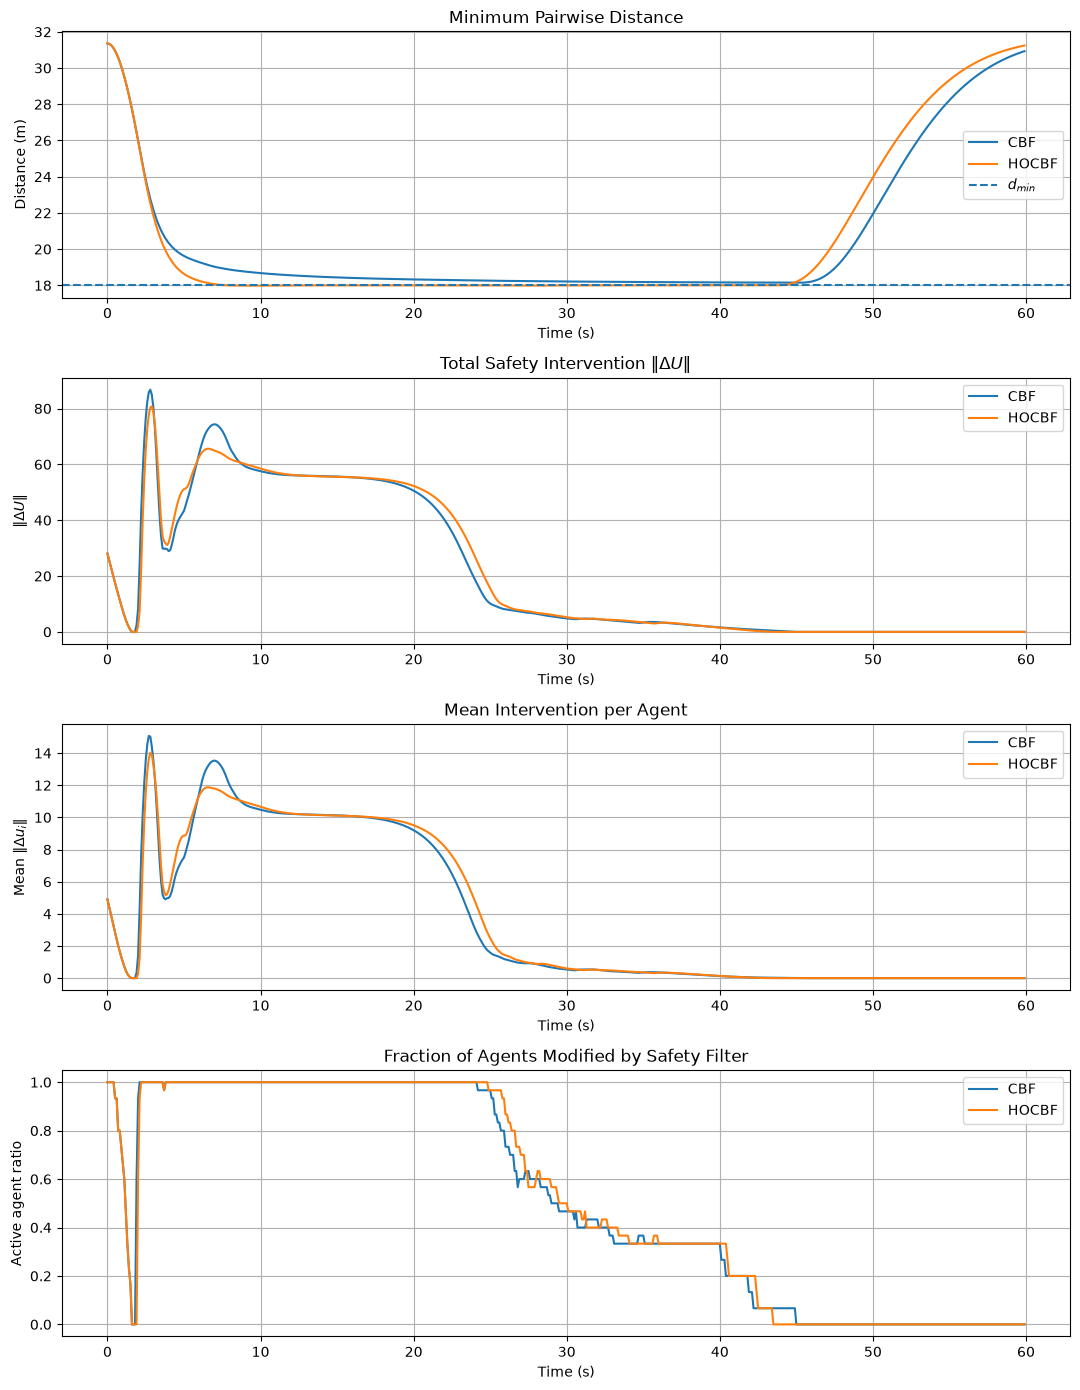

In [25]:
# ============================================================
# Final CBF vs HOCBF comparison
# ============================================================

# Mean intervention per agent
mean_delta_u_cbf = np.mean(delta_u_hist_cbf, axis=1)
mean_delta_u_hocbf = np.mean(delta_u_hist_hocbf, axis=1)

# Fraction of agents being modified by safety filter
eps_agent = 1e-3

active_ratio_cbf = np.mean(delta_u_hist_cbf > eps_agent, axis=1)
active_ratio_hocbf = np.mean(delta_u_hist_hocbf > eps_agent, axis=1)

# Safety margin
safety_margin_cbf = min_dist_hist_cbf - d_min
safety_margin_hocbf = min_dist_hist_hocbf - d_min


# ============================================================
# Print summary table
# ============================================================

print("\n================ CBF vs HOCBF COMPARISON ================\n")

print(f"{'Metric':<28} {'CBF':>12} {'HOCBF':>12}")
print("-" * 54)

print(f"{'Intervention start [s]':<28} "
      f"{t_start_cbf:>12.3f} {t_start_hocbf:>12.3f}")

print(f"{'Intervention end [s]':<28} "
      f"{t_end_cbf:>12.3f} {t_end_hocbf:>12.3f}")

print(f"{'Active duration [s]':<28} "
      f"{active_duration_cbf:>12.3f} {active_duration_hocbf:>12.3f}")

print(f"{'Peak intervention':<28} "
      f"{peak_intervention_cbf:>12.3f} {peak_intervention_hocbf:>12.3f}")

print(f"{'Intervention effort':<28} "
      f"{intervention_effort_cbf:>12.3f} {intervention_effort_hocbf:>12.3f}")

print(f"{'Minimum distance [m]':<28} "
      f"{min_distance_cbf:>12.3f} {min_distance_hocbf:>12.3f}")

print(f"{'Safety margin [m]':<28} "
      f"{min_distance_cbf-d_min:>12.3f} {min_distance_hocbf-d_min:>12.3f}")

print(f"{'Peak mean intervention':<28} "
      f"{np.max(mean_delta_u_cbf):>12.3f} {np.max(mean_delta_u_hocbf):>12.3f}")

print(f"{'Max active agent ratio':<28} "
      f"{np.max(active_ratio_cbf):>12.3f} {np.max(active_ratio_hocbf):>12.3f}")


# ============================================================
# Plot comparison
# ============================================================

fig, ax = plt.subplots(4, 1, figsize=(11, 14))

# ------------------------------------------------------------
# 1. Minimum pairwise distance
# ------------------------------------------------------------
ax[0].plot(time, min_dist_hist_cbf, label="CBF")
ax[0].plot(time, min_dist_hist_hocbf, label="HOCBF")
ax[0].axhline(d_min, linestyle="--", label=r"$d_{min}$")

ax[0].set_title("Minimum Pairwise Distance")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Distance (m)")
ax[0].grid(True)
ax[0].legend()


# ------------------------------------------------------------
# 2. Total system intervention
# ------------------------------------------------------------
ax[1].plot(time, delta_u_total_cbf, label="CBF")
ax[1].plot(time, delta_u_total_hocbf, label="HOCBF")

ax[1].set_title(r"Total Safety Intervention $\|\Delta U\|$")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(r"$\|\Delta U\|$")
ax[1].grid(True)
ax[1].legend()


# ------------------------------------------------------------
# 3. Mean intervention per agent
# ------------------------------------------------------------
ax[2].plot(time, mean_delta_u_cbf, label="CBF")
ax[2].plot(time, mean_delta_u_hocbf, label="HOCBF")

ax[2].set_title(r"Mean Intervention per Agent")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel(r"Mean $\|\Delta u_i\|$")
ax[2].grid(True)
ax[2].legend()


# ------------------------------------------------------------
# 4. Fraction of active agents
# ------------------------------------------------------------
ax[3].plot(time, active_ratio_cbf, label="CBF")
ax[3].plot(time, active_ratio_hocbf, label="HOCBF")

ax[3].set_title("Fraction of Agents Modified by Safety Filter")
ax[3].set_xlabel("Time (s)")
ax[3].set_ylabel("Active agent ratio")
ax[3].set_ylim(-0.05, 1.05)
ax[3].grid(True)
ax[3].legend()

plt.tight_layout()
plt.show()